Shape of dataset: (200, 4)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

First 5 Rows:
      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
            TV    Radio  Newspaper    Sales
count  200.000  200.000    200.000  200.000
mean   147.042   23.264     30.554   14.023
std     85.854   14.847     21.779    5.217
min      0.700    0.000      0.300    1.600
25%     

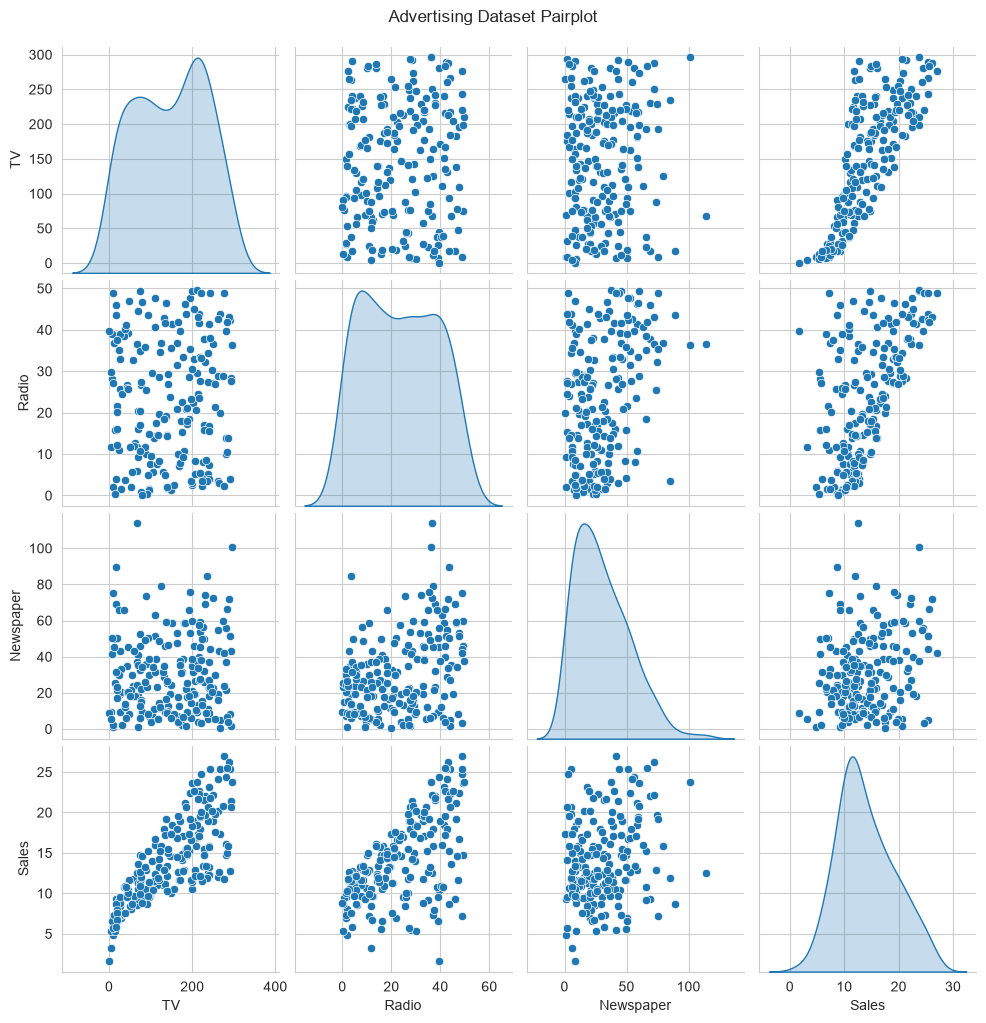

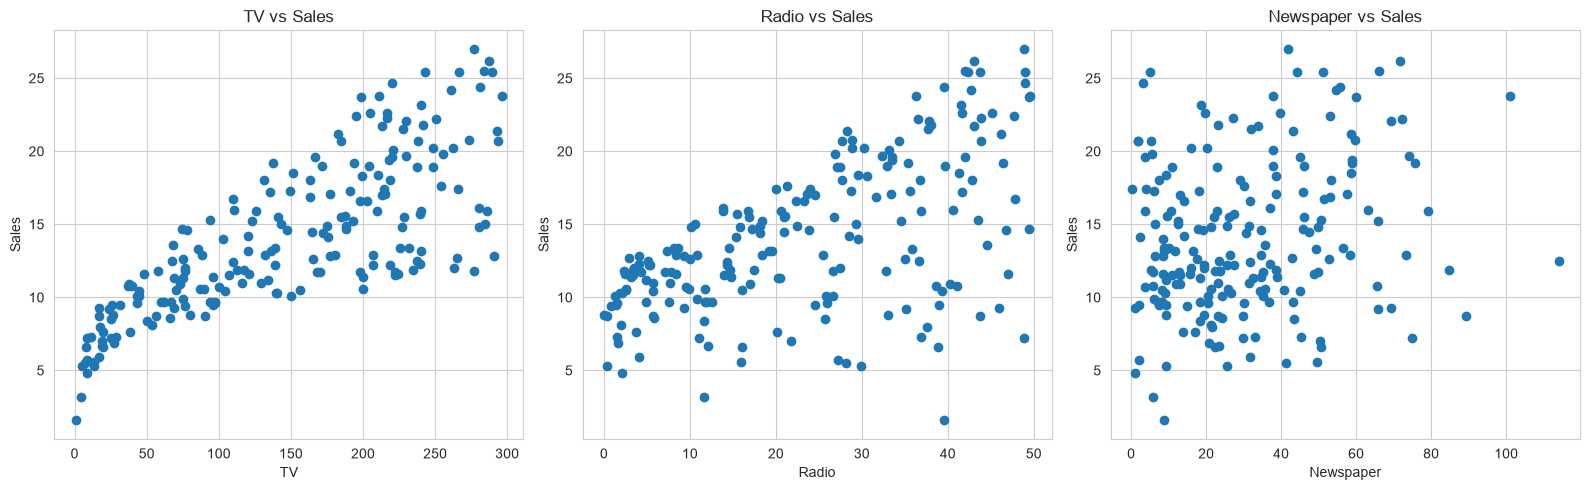

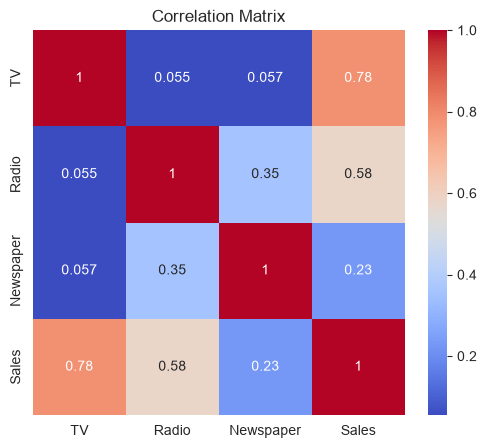


Training Shape: (160, 3)
Testing Shape: (40, 3)

Linear Regression Coefficients
     Feature  Coefficient
1      Radio        0.189
0         TV        0.045
2  Newspaper        0.003

Random Forest Feature Importance
     Feature  Importance
0         TV       0.625
1      Radio       0.362
2  Newspaper       0.013

Model Comparison
               Model    MAE   RMSE     R2
0  Linear Regression  1.461  1.782  0.899
1      Random Forest  0.614  0.741  0.983


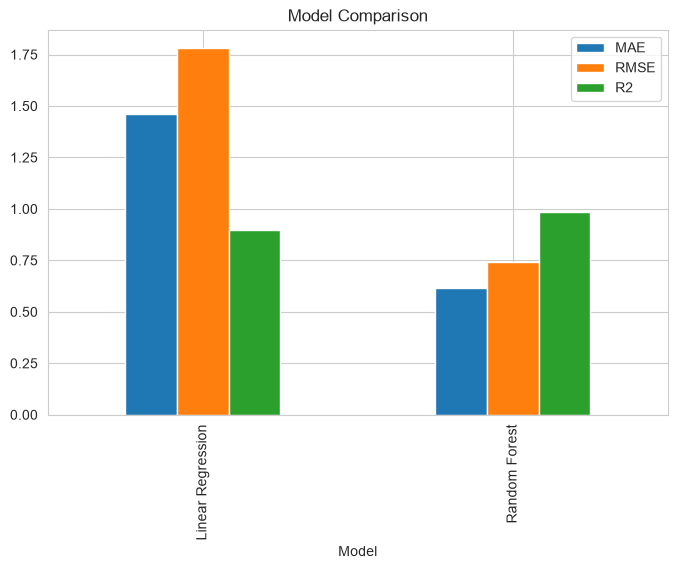


Best Model: Random Forest


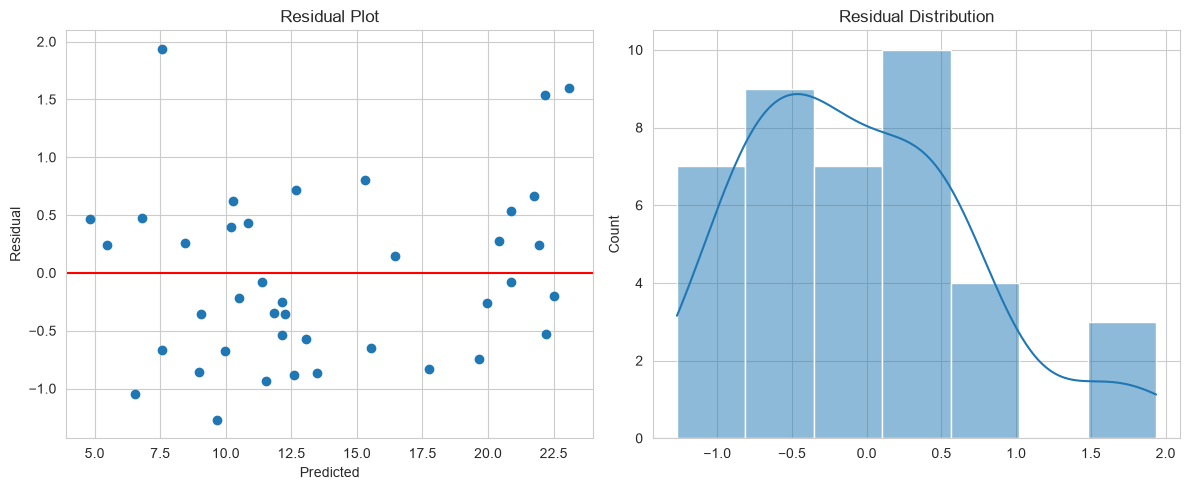


Standardized Coefficients
     Feature  Standardized Coefficient
0         TV                     3.764
1      Radio                     2.792
2  Newspaper                     0.056


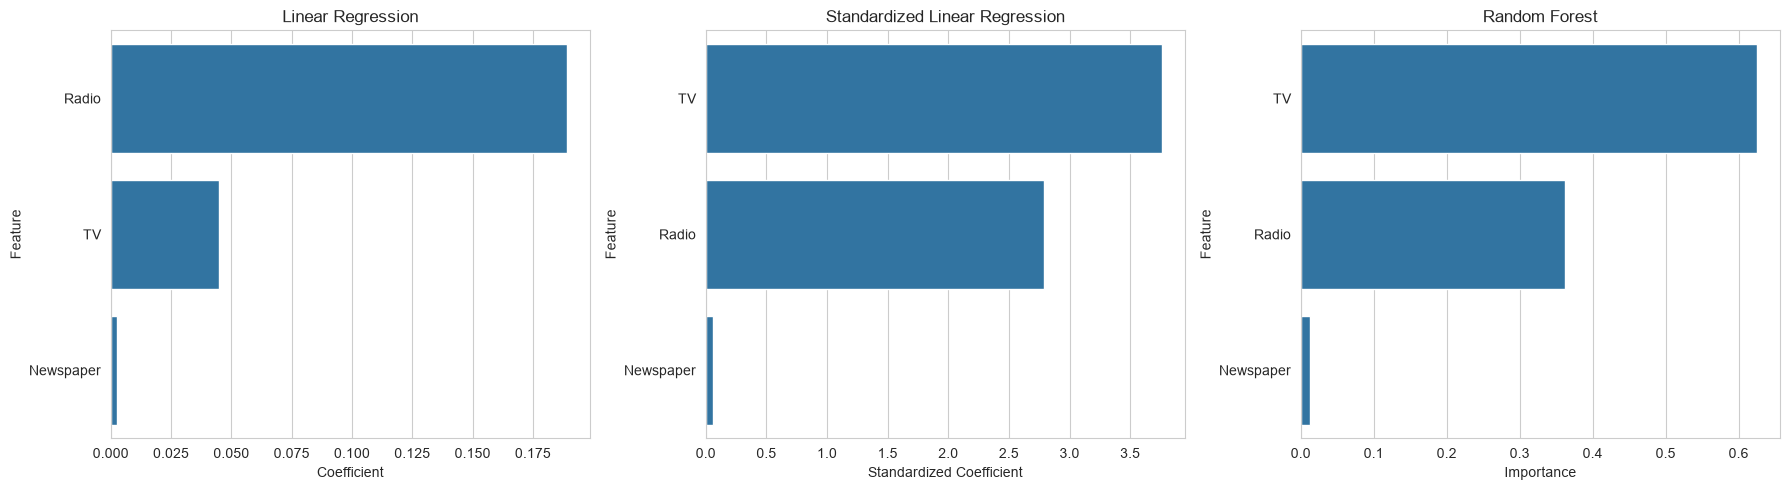


Top Feature (Raw Coefficient): Radio
Top Feature (Standardized): TV
Top Feature (Random Forest): TV


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Settings
# -----------------------------
sns.set_style("whitegrid")
pd.set_option("display.precision", 3)

RANDOM_STATE = 42

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Advertising.csv", index_col=0)

print("Shape of dataset:", df.shape)
print("\nDataset Information:")
df.info()

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# Pairplot
# -----------------------------
sns.pairplot(df, diag_kind="kde")
plt.suptitle("Advertising Dataset Pairplot", y=1.02)
plt.show()

# -----------------------------
# Scatter Plots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, col in zip(axes, ["TV","Radio","Newspaper"]):
    ax.scatter(df[col], df["Sales"])
    ax.set_xlabel(col)
    ax.set_ylabel("Sales")
    ax.set_title(f"{col} vs Sales")

plt.tight_layout()
plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# Features and Target
# -----------------------------
X = df[["TV","Radio","Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nLinear Regression Coefficients")
print(coef_df)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance")
print(importance_df)

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_lin, "Linear Regression"),
    evaluate(y_test, y_pred_rf, "Random Forest")
])

print("\nModel Comparison")
print(results)

results.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Model Comparison")
plt.show()

best_model = "Random Forest" if results.loc[1,"R2"] > results.loc[0,"R2"] else "Linear Regression"

best_pred = y_pred_rf if best_model=="Random Forest" else y_pred_lin

print("\nBest Model:", best_model)

residuals = y_test.values - best_pred

fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(best_pred, residuals)
axes[0].axhline(0,color="red")
axes[0].set_title("Residual Plot")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

sns.histplot(residuals,kde=True,ax=axes[1])
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

lin_std = LinearRegression()
lin_std.fit(X_train_scaled,y_train)

std_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Standardized Coefficient": lin_std.coef_
}).sort_values(by="Standardized Coefficient",ascending=False)

print("\nStandardized Coefficients")
print(std_coef_df)


fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.barplot(data=coef_df,x="Coefficient",y="Feature",ax=axes[0])
axes[0].set_title("Linear Regression")

sns.barplot(data=std_coef_df,x="Standardized Coefficient",y="Feature",ax=axes[1])
axes[1].set_title("Standardized Linear Regression")

sns.barplot(data=importance_df,x="Importance",y="Feature",ax=axes[2])
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

print("\nTop Feature (Raw Coefficient):", coef_df.iloc[0]["Feature"])
print("Top Feature (Standardized):", std_coef_df.iloc[0]["Feature"])
print("Top Feature (Random Forest):", importance_df.iloc[0]["Feature"])